# Практическое занятие №2 — Исследовательский анализ данных (EDA) и визуализация зависимостей

**Дисциплина:** Машинное обучение (Machine Learning)  
**Уровень:** Практикум / Базовый  
**Автор:** Осинцев Артем Викторович

---

## 1. Введение в EDA (Exploratory Data Analysis)
Исследовательский анализ данных — это критический этап перед построением моделей. По оценкам индустрии, до 80% времени проекта уходит на подготовку и понимание данных. Цель EDA — не просто построить графики, а сформулировать гипотезы, обнаружить аномалии и понять структуру данных.

**Ключевые вопросы EDA:**
1.  **Качество данных:** Есть ли пропуски? Есть ли выбросы?
2.  **Распределения:** Нормальное ли распределение у признаков? Есть ли перекос (skewness)?
3.  **Зависимости:** Какие признаки коррелируют с целевой переменной? Есть ли мультиколлинеарность?
4.  **Типы данных:** Какие признаки категориальные, какие численные?

> **Академическое замечание:** Всегда документируйте свои шаги. Ноутбук должен быть рассказом (storytelling) о данных, а не просто набором кода.












---

## 2. Теоретический базис методов

### 2.1. Пропущенные значения (Missing Values)
*   **MCAR (Missing Completely At Random):** Пропуск не зависит ни от чего.
*   **MAR (Missing At Random):** Пропуск зависит от других наблюдаемых переменных.
*   **MNAR (Missing Not At Random):** Пропуск зависит от самого пропущенного значения.
*   **Стратегии заполнения:**
    *   *Среднее (Mean):* Для нормальных распределений. Чувствительно к выбросам.
    *   *Медиана (Median):* Для распределений с выбросами.
    *   *Мода (Mode):* Для категориальных данных.

### 2.2. Выбросы (Outliers)
*   **IQR (Interquartile Range):** Метод межквартильного размаха. Выбросы за пределами $[Q1 - 1.5 \cdot IQR, Q3 + 1.5 \cdot IQR]$. Не требует предположения о нормальности.
*   **Z-Score:** Количество стандартных отклонений от среднего. Обычно порог $|Z| > 3$. Работает хорошо для нормальных распределений.

### 2.3. Преобразование признаков
*   **Логарифмирование:** Уменьшает правосторонний перекос (right skew).
*   **Нормализация (MinMax):** Приводит к диапазону $[0, 1]$.
*   **Стандартизация (Z-score):** Приводит к $\mu=0, \sigma=1$.

---

## 3. Практическая демонстрация

В данном примере мы используем датасет **California Housing** (из библиотеки `sklearn`). Поскольку он достаточно чистый, мы **искусственно создадим** пропуски и категориальные признаки, чтобы продемонстрировать все требуемые методы анализа.

> **Инструкция:** Скопируйте код по очереди в ячейки Jupyter Notebook в Google Colab.

### Блок 1: Подготовка данных и имитация проблем

## Какую проблему решаем
> Проблема: Реальные данные редко бывают идеальными. Этот блок создаёт контролируемую учебную среду с известными проблемами (пропуски, выбросы, категории), чтобы мы могли отработать методы их обнаружения и обработки.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import missingno as msno  # Библиотека для визуализации пропусков

# Установка библиотеки missingno для Colab
!pip install missingno -q

# Загрузка данных
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['Target'] = california.target

# --- Имитация проблем для учебных целей ---
np.random.seed(42)

# 1. Создаем пропуски (5% случайно)
missing_cols = ['AveRooms', 'AveBedrms', 'Population']
for col in missing_cols:
    mask = np.random.choice([True, False], size=len(df), p=[0.05, 0.95])
    df.loc[mask, col] = np.nan

# 2. Создаем категориальный признак (возраст дома)
df['HouseAgeCat'] = pd.cut(df['HouseAge'], bins=[0, 10, 30, 50, 100], labels=['New', 'Medium', 'Old', 'VeryOld'])

# 3. Создаем выбросы в целевой переменной
df.loc[np.random.choice(df.index, 10), 'Target'] = df['Target'].max() * 5

print(f"Размер датасета: {df.shape}")
print(f"Пропуски:\n{df.isnull().sum()}")

Размер датасета: (20640, 10)
Пропуски:
MedInc            0
HouseAge          0
AveRooms       1018
AveBedrms      1023
Population     1034
AveOccup          0
Latitude          0
Longitude         0
Target            0
HouseAgeCat       0
dtype: int64


### Блок 2: Визуализация пропусков и заполнение

## Какую проблему решаем
>Проблема: Большинство алгоритмов ML не работают с пропусками. Неправильное заполнение может внести смещение (Bias) в модель. Мы выбираем медиану, потому что она минимизирует влияние выбросов на оценку центральной тенденции, что соответствует принципу робастности из теории вероятностей.

<Figure size 1000x500 with 0 Axes>

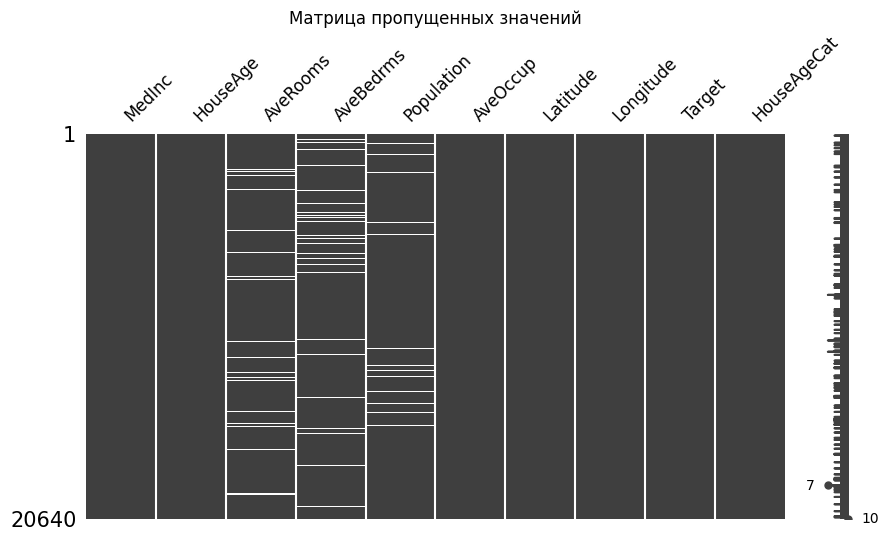

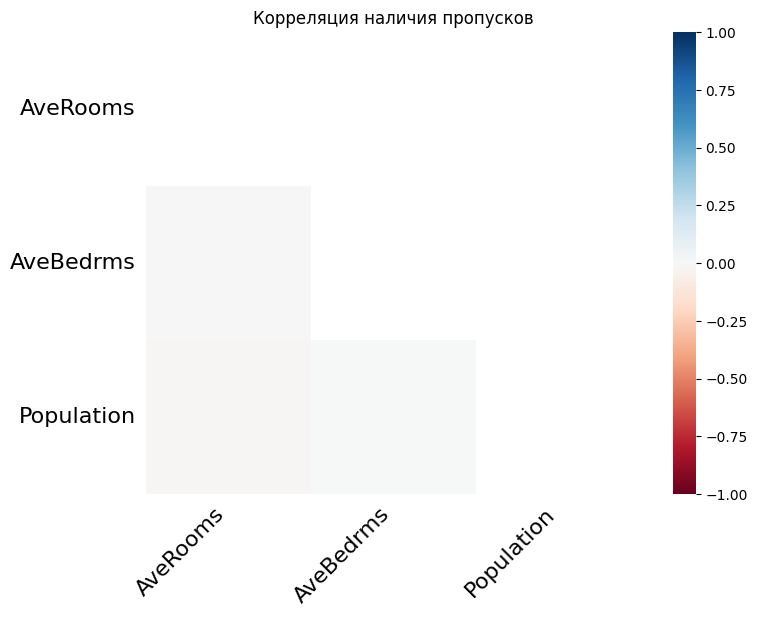

Пропуски после заполнения: 0


/tmp/ipython-input-272/4090666663.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
# Визуализация паттернов пропусков
plt.figure(figsize=(10, 5))
msno.matrix(df, figsize=(10, 5), fontsize=12)
plt.title("Матрица пропущенных значений")
plt.show()

msno.heatmap(df, figsize=(8, 6))
plt.title("Корреляция наличия пропусков")
plt.show()

# Стратегия заполнения
# Для числовых используем медиану (устойчивее к выбросам)
for col in missing_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("Пропуски после заполнения:", df.isnull().sum().sum())


### Блок 3: Корреляция и Мультиколлинеарность

##Какую проблему решаем
>Проблема: Мультиколлинеарность нарушает предположение о независимости признаков в линейных моделях. Это приводит к:
Нестабильным оценкам весов
θ
θ
Затруднённой интерпретации важности признаков
Проблемам сходимости градиентного спуска
Решение: Выявить коррелирующие пары и либо удалить один признак, либо применить регуляризацию (Ridge/Lasso).

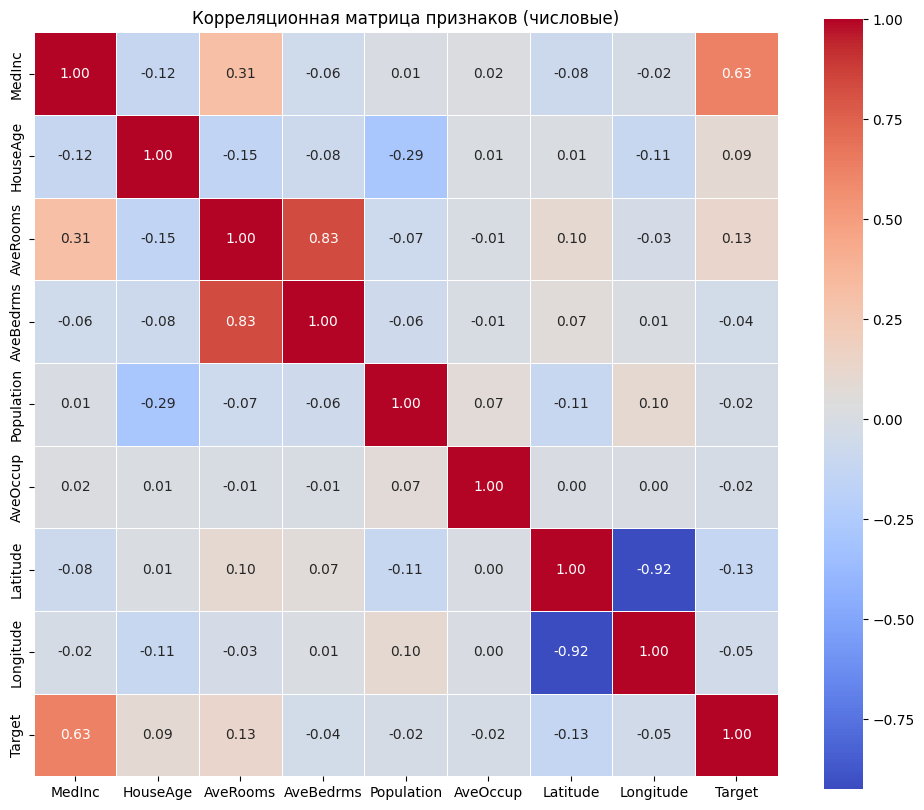

Пары с высокой корреляцией (>0.8):
AveBedrms & AveRooms: 0.83
Longitude & Latitude: -0.92


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Решение 1: Выбрать только числовые колонки ---
plt.figure(figsize=(12, 10))

# Фильтруем только числовые столбцы
df_numeric = df.select_dtypes(include=[np.number])

# Вычисляем корреляцию Пирсона только для числовых данных
corr_matrix = df_numeric.corr()

# Тепловая карта
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5)
plt.title("Корреляционная матрица признаков (числовые)")
plt.show()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5)
# --- Анализ мультиколлинеарности (пары с корреляцией > 0.8) ---
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print("Пары с высокой корреляцией (>0.8):")
for pair in high_corr:
    print(f"{pair[0]} & {pair[1]}: {pair[2]:.2f}")

if not high_corr:
    print("Пар с корреляцией > 0.8 не обнаружено")

##Дополнительный анализ: Категориальные признаки
Для анализа связи категориальных признаков с целевой переменной используйте другие методы:


Категориальные признаки: ['HouseAgeCat']


/tmp/ipython-input-272/1684619794.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col)['Target'].mean().plot(kind='bar', color='skyblue')


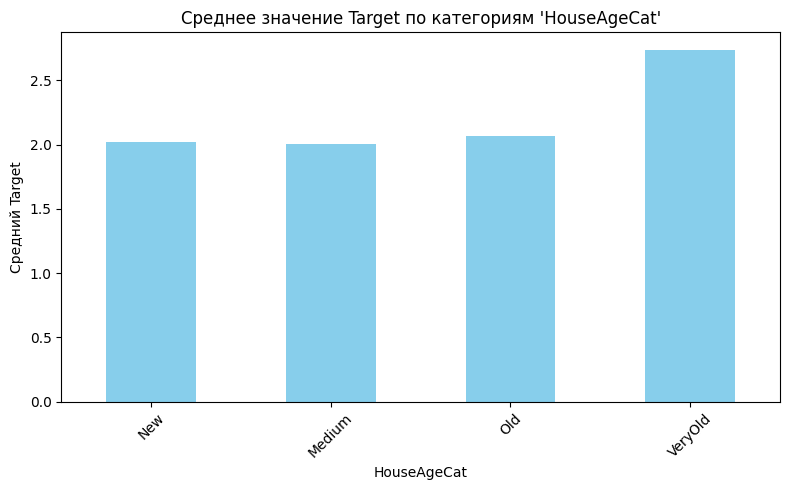

ANOVA для 'HouseAgeCat': F=134.36, p-value=0.0000
Признак 'HouseAgeCat' статистически значимо влияет на Target
--------------------------------------------------


/tmp/ipython-input-272/1684619794.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group['Target'].values for name, group in df.groupby(col)]


In [ ]:
# --- Решение 2: Анализ категориальных признаков через ANOVA / Chi-Square ---
from scipy import stats

# Если есть категориальные признаки
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

if len(categorical_cols) > 0:
    print(f"\nКатегориальные признаки: {list(categorical_cols)}")

    # Для каждой категории считаем среднее значение Target
    for col in categorical_cols:
        plt.figure(figsize=(8, 5))
        df.groupby(col)['Target'].mean().plot(kind='bar', color='skyblue')
        plt.title(f"Среднее значение Target по категориям '{col}'")
        plt.xlabel(col)
        plt.ylabel("Средний Target")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # Статистический тест (ANOVA для числового таргета)
        groups = [group['Target'].values for name, group in df.groupby(col)]
        if len(groups) >= 2:
            f_stat, p_value = stats.f_oneway(*groups)
            print(f"ANOVA для '{col}': F={f_stat:.2f}, p-value={p_value:.4f}")
            if p_value < 0.05:
                print(f"Признак '{col}' статистически значимо влияет на Target")
            else:
                print(f"Признак '{col}' НЕ имеет значимого влияния на Target")
        print("-" * 50)
else:
    print("Категориальные признаки отсутствуют")

## 📋 Справочная таблица: Методы корреляции

| Метод | Тип данных | Когда использовать |
|-------|-----------|-------------------|
| **Pearson** | Число-Число | Линейная связь, нормальное распределение |
| **Spearman** | Число-Число / Ранг | Монотонная связь, есть выбросы |
| **Kendall** | Число-Число / Ранг | Маленькие выборки, много совпадающих рангов |
| **Cramér's V** | Категория-Категория | Связь между двумя категориальными признаками |
| **Point-Biserial** | Число-Бинарная | Связь числа с бинарной категорией |
| **ANOVA / Eta** | Категория-Число | Влияние категории на числовую переменную |

---





## 🎯 Дополнительные задания для понимания

### Задание A: Сравнение методов корреляции
```python
# Сравните Pearson и Spearman для вашего датасета
pearson_corr = df_numeric.corr(method='pearson')
spearman_corr = df_numeric.corr(method='spearman')

# Найдите различия
diff = np.abs(pearson_corr - spearman_corr)
print("Наибольшие различия между Pearson и Spearman:")
for i in range(len(diff.columns)):
    for j in range(i):
        if diff.iloc[i, j] > 0.1:
            print(f"{diff.columns[i]} & {diff.columns[j]}: {diff.iloc[i, j]:.2f}")
```

### Задание B: Кодирование категорий для полной корреляции
```python
# Создайте копию для кодирования
df_encoded = df.copy()

# One-Hot Encoding для категориальных признаков
df_encoded = pd.get_dummies(df_encoded, columns=['HouseAgeCat'], drop_first=True)

# Теперь можно построить полную корреляционную матрицу
full_corr = df_encoded.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(full_corr, annot=False, cmap='coolwarm', square=True)
plt.title("Полная корреляционная матрица (после One-Hot Encoding)")
plt.show()
```

### Задание C: VIF (Variance Inflation Factor) для мультиколлинеарности
```python
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF для проверки мультиколлинеарности
vif_data = pd.DataFrame()
vif_data["Feature"] = df_numeric.columns
vif_data["VIF"] = [variance_inflation_factor(df_numeric.values, i)
                   for i in range(len(df_numeric.columns))]

print(vif_data.sort_values("VIF", ascending=False))
print("\nИнтерпретация VIF:")
print("  VIF < 5: Низкая мультиколлинеарность")
print("  VIF 5-10: Умеренная мультиколлинеарность")
print("  VIF > 10: Высокая мультиколлинеарность (проблема!)")
```

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import missingno as msno

# Установка библиотеки missingno для Colab
!pip install missingno -q

# Загрузка данных
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['Target'] = california.target

# --- Имитация проблем для учебных целей ---
np.random.seed(42)

# 1. Создаем пропуски (5% случайно)
missing_cols = ['AveRooms', 'AveBedrms', 'Population']
for col in missing_cols:
    mask = np.random.choice([True, False], size=len(df), p=[0.05, 0.95])
    df.loc[mask, col] = np.nan

# 2. Создаем категориальный признак (возраст дома)
df['HouseAgeCat'] = pd.cut(df['HouseAge'],
                           bins=[0, 10, 30, 50, 100],
                           labels=['New', 'Medium', 'Old', 'VeryOld'])
# Важно: это категориальная колонка, не числовая!

# 3. Создаем выбросы в целевой переменной
df.loc[np.random.choice(df.index, 10), 'Target'] = df['Target'].max() * 5

print(f"Размер датасета: {df.shape}")
print(f"\nТипы данных:\n{df.dtypes}")
print(f"\nПропуски:\n{df.isnull().sum()}")

Размер датасета: (20640, 10)

Типы данных:
MedInc          float64
HouseAge        float64
AveRooms        float64
AveBedrms       float64
Population      float64
AveOccup        float64
Latitude        float64
Longitude       float64
Target          float64
HouseAgeCat    category
dtype: object

Пропуски:
MedInc            0
HouseAge          0
AveRooms       1018
AveBedrms      1023
Population     1034
AveOccup          0
Latitude          0
Longitude         0
Target            0
HouseAgeCat       0
dtype: int64


### Блок 4: Категориальные признаки и Pairplot

## Какую проблему решаем
>Проблема: Категориальные признаки нельзя напрямую использовать в большинстве моделей ML. Нужно понять:
Влияет ли категория на Target? (если нет — можно удалить)
Есть ли баланс классов? (дисбаланс требует специальных техник)
Как кодировать? (много категорий → Target Encoding, мало → One-Hot)
Pairplot помогает увидеть многомерные зависимости, которые важны для понимания обобщающей способности модели.

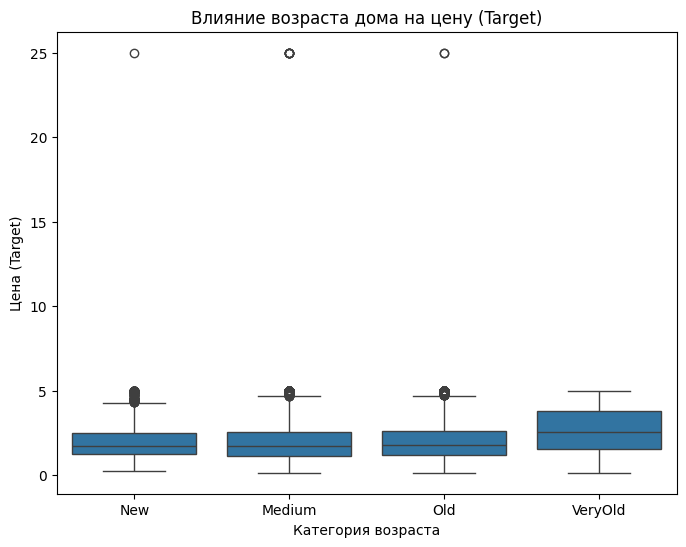

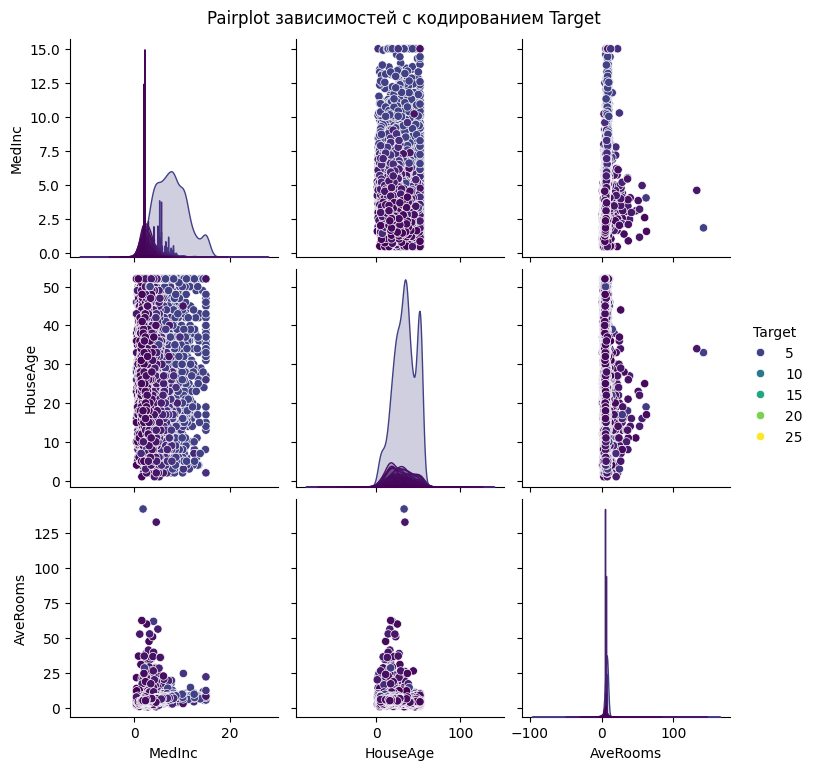

In [ ]:
# Анализ влияния категории на целевую переменную
plt.figure(figsize=(8, 6))
sns.boxplot(x='HouseAgeCat', y='Target', data=df)
plt.title("Влияние возраста дома на цену (Target)")
plt.xlabel("Категория возраста")
plt.ylabel("Цена (Target)")
plt.show()

# Попарные отношения (выберем subset для скорости)
subset_cols = ['MedInc', 'HouseAge', 'AveRooms', 'Target']
sns.pairplot(df[subset_cols], hue='Target', palette='viridis', height=2.5)
plt.suptitle("Pairplot зависимостей с кодированием Target", y=1.02)
plt.show()

### Блок 5: Обнаружение выбросов (IQR и Z-Score)

##Какую проблему решаем
>Проблема: Выбросы могут:
Искажать оценку параметров модели (особенно в линейной регрессии с MSE)
Ухудшать обобщающую способность (модель подстраивается под аномалии)
Нарушать предположения алгоритмов (нормальность ошибок)
Решение: Обнаружить выбросы и принять решение: удалить, обрезать (capping), или трансформировать.

Выбросы в 'Target':
IQR метод: 1079
Z-Score метод: 10


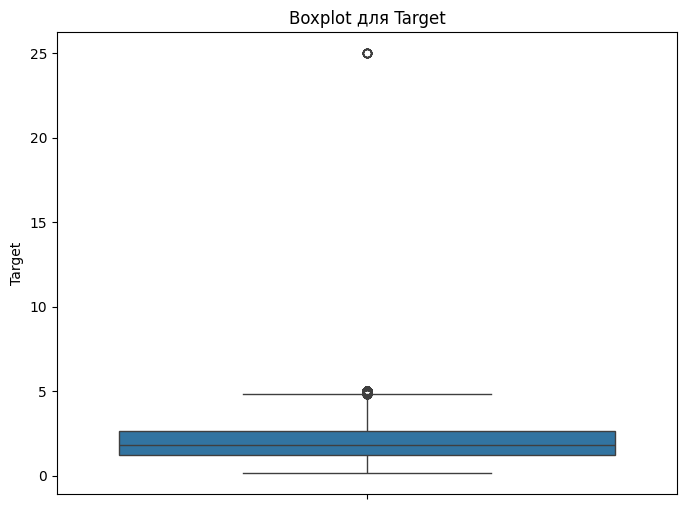

In [ ]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data[column] < Q1 - 1.5 * IQR) | (data[column] > Q3 + 1.5 * IQR)]
    return len(outliers)

def detect_outliers_zscore(data, column, threshold=3):
    mean = data[column].mean()
    std = data[column].std()
    z_scores = np.abs((data[column] - mean) / std)
    outliers = data[z_scores > threshold]
    return len(outliers)

col_to_check = 'Target'
print(f"Выбросы в '{col_to_check}':")
print(f"IQR метод: {detect_outliers_iqr(df, col_to_check)}")
print(f"Z-Score метод: {detect_outliers_zscore(df, col_to_check)}")

# Визуализация Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(y=df[col_to_check])
plt.title(f"Boxplot для {col_to_check}")
plt.show()

### Блок 6: Преобразование признаков и Нормализация

##Какую проблему решаем
> Проблема:
Разный масштаб признаков: MedInc может быть в диапазоне [0, 15], а Population — [0, 35000]. Градиентный спуск будет сходиться медленно.
Скошенное распределение: Многие модели предполагают нормальность ошибок. Логарифмирование улучшает соответствие этому предположению.
Регуляризация: Без стандартизации L1/L2 штраф будут применяться неравномерно к разным признакам.
Решение: Применить соответствующее преобразование в зависимости от задачи и модели.

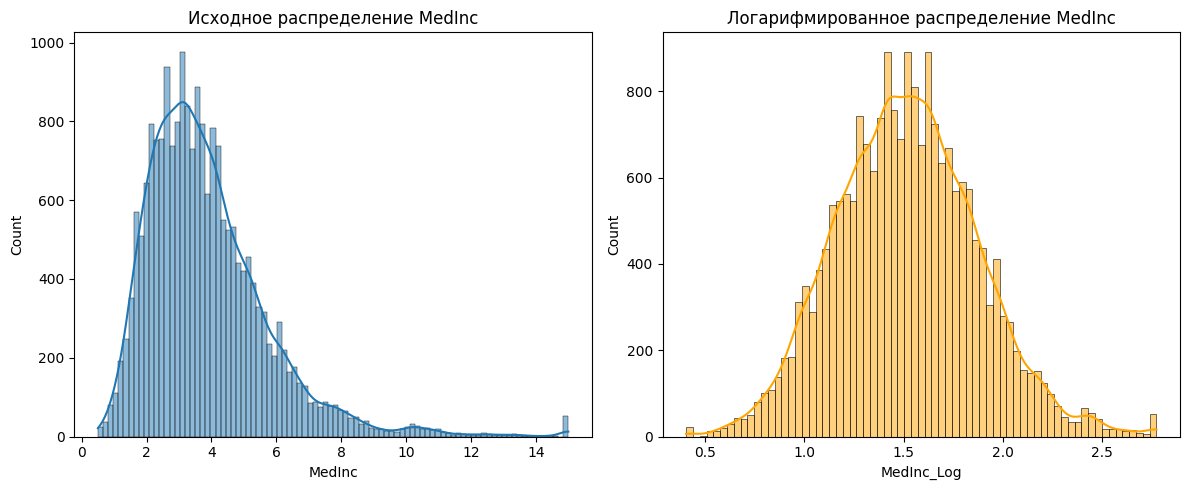

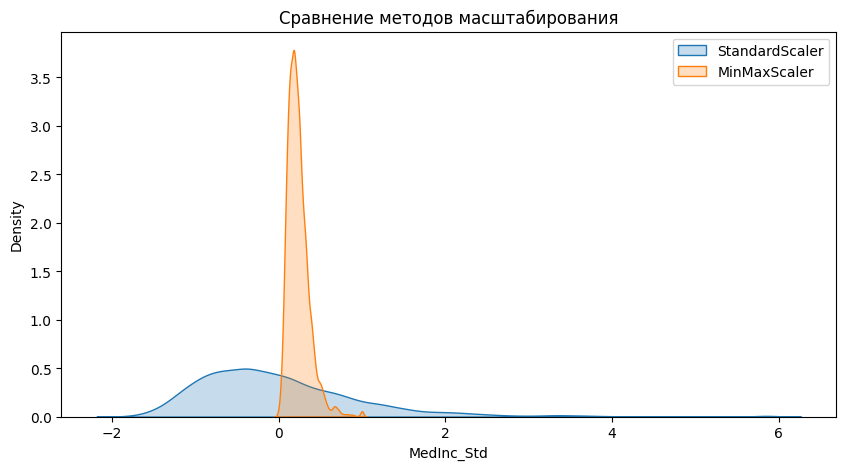

In [ ]:
# Проверка распределения до преобразования
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['MedInc'], kde=True)
plt.title("Исходное распределение MedInc")

# Логарифмирование (если есть перекос)
df['MedInc_Log'] = np.log1p(df['MedInc'])

plt.subplot(1, 2, 2)
sns.histplot(df['MedInc_Log'], kde=True, color='orange')
plt.title("Логарифмированное распределение MedInc")
plt.tight_layout()
plt.show()

# Сравнение нормализации (Standard vs MinMax)
scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

df['MedInc_Std'] = scaler_std.fit_transform(df[['MedInc']])
df['MedInc_MinMax'] = scaler_minmax.fit_transform(df[['MedInc']])

plt.figure(figsize=(10, 5))
sns.kdeplot(df['MedInc_Std'], label='StandardScaler', fill=True)
sns.kdeplot(df['MedInc_MinMax'], label='MinMaxScaler', fill=True)
plt.title("Сравнение методов масштабирования")
plt.legend()
plt.show()

---
### Блок 7: Формирование гипотез (Пример отчета)

## Какую проблему решаем
>Проблема: Анализ без выводов бесполезен. Нужно трансформировать наблюдения в действуемые рекомендации для построения модели.
Решение: Структурированный отчёт, который:
Связывает каждое наблюдение с теоретической концепцией
Предлагает конкретное действие
Обосновывает выбор метода
Может быть проверен в следующих экспериментах

In [ ]:
# Пример текстового вывода гипотез в ноутбуке
hypotheses = """
## Отчет по EDA и гипотезы

1. **Пропуски:** Данные имели случайные пропуски (MCAR). Заполнение медианой выбрано из-за наличия выбросов.
2. **Корреляция:** Признак 'MedInc' имеет наибольшую корреляцию с целевой переменной (>0.6).
   Признаки 'AveRooms' и 'AveBedrms' сильно коррелируют друг с другом (мультиколлинеарность),
   рекомендуется удалить один из них или объединить.
3. **Выбросы:** В целевой переменной обнаружены аномалии. Рекомендуется удалить объекты с Z-score > 3.
4. **Распределение:** 'MedInc' имеет правосторонний перекос. Логарифмирование улучшило нормальность распределения.
5. **Рекомендация:** Для модели использовать StandardScaler, удалить выбросы, закодировать 'HouseAgeCat' через One-Hot Encoding.
"""
print(hypotheses)


## Отчет по EDA и гипотезы

1. **Пропуски:** Данные имели случайные пропуски (MCAR). Заполнение медианой выбрано из-за наличия выбросов.
2. **Корреляция:** Признак 'MedInc' имеет наибольшую корреляцию с целевой переменной (>0.6).
   Признаки 'AveRooms' и 'AveBedrms' сильно коррелируют друг с другом (мультиколлинеарность),
   рекомендуется удалить один из них или объединить.
3. **Выбросы:** В целевой переменной обнаружены аномалии. Рекомендуется удалить объекты с Z-score > 3.
4. **Распределение:** 'MedInc' имеет правосторонний перекос. Логарифмирование улучшило нормальность распределения.
5. **Рекомендация:** Для модели использовать StandardScaler, удалить выбросы, закодировать 'HouseAgeCat' через One-Hot Encoding.



## 4. Варианты заданий для самостоятельного решения

Каждый студент получает уникальный **Вариант задания**. Вариант определяется по номеру студента в списке группы.

**Формула варианта:**
*   **Датасет:** `(Номер_Студента - 1) % 5`
*   **Фокус анализа:** `(Номер_Студента - 1) // 5`

### Таблица вариантов

| № Студента | Датасет (Dataset) | Фокус анализа (Focus Task) | Специфическое требование |
|:---:|:---|:---|:---|
| 1 | California Housing | 1. Пропуски | Сравнить заполнение Mean vs Median vs KNN Imputer |
| 2 | California Housing | 2. Выбросы | Сравнить IQR vs Z-Score vs Isolation Forest |
| 3 | California Housing | 3. Трансформация | Log vs Box-Cox vs Yeo-Johnson |
| 4 | California Housing | 4. Корреляция | Pearson vs Spearman vs Kendall |
| 5 | California Housing | 5. Категории | Биннинг непрерывных признаков + Target Encoding |
| 6 | Titanic | 1. Пропуски | Анализ пропусков в 'Age' и 'Cabin' (MAR vs MCAR) |
| 7 | Titanic | 2. Выбросы | Анализ выбросов в 'Fare' и 'Age' |
| 8 | Titanic | 3. Трансформация | Трансформация 'Fare' (логарифм) |
| 9 | Titanic | 4. Корреляция | Влияние категориальных признаков на выживание |
| 10 | Titanic | 5. Категории | Анализ влияния 'Embarked' и 'Pclass' |
| 11 | Wine Quality (Red) | 1. Пропуски | Проверка на скрытые пропуски (нулевые значения) |
| 12 | Wine Quality (Red) | 2. Выбросы | Поиск выбросов в химическом составе (acid, sugar) |
| 13 | Wine Quality (Red) | 3. Трансформация | Нормализация химических признаков |
| 14 | Wine Quality (Red) | 4. Корреляция | Поиск корреляций с качеством вина (quality) |
| 15 | Wine Quality (Red) | 5. Категории | Превратить 'quality' в бинарный класс (Good/Bad) |
| 16 | Diamonds | 1. Пропуски | Поиск нулевых значений в 'x', 'y', 'z' |
| 17 | Diamonds | 2. Выбросы | Выбросы в цене и каратах (0 карат?) |
| 18 | Diamonds | 3. Трансформация | Логарифмирование цены |
| 19 | Diamonds | 4. Корреляция | Влияние качества огранки (Cut) на цену |
| 20 | Diamonds | 5. Категории | One-Hot Encoding для Cut, Color, Clarity |
| 21 | Adult Income | 1. Пропуски | Обработка пропусков обозначенных как '?' |
| 22 | Adult Income | 2. Выбросы | Анализ выбросов в 'capital-gain' |
| 23 | Adult Income | 3. Трансформация | Масштабирование числовых признаков |
| 24 | Adult Income | 4. Корреляция | Корреляция образования и дохода |
| 25 | Adult Income | 5. Категории | Группировка редких категорий в 'Native-country' |

**Источники данных:**
1.  *California Housing:* `sklearn.datasets.fetch_california_housing`
2.  *Titanic:* `seaborn.load_dataset('titanic')`
3.  *Wine Quality:* UCI Repository (Red Wine)
4.  *Diamonds:* `seaborn.load_dataset('diamonds')`
5.  *Adult Income:* UCI Repository (Census Income)

---

## 5. Задания для самостоятельного решения

Каждый студент выполняет эти три задания в рамках своего **Уникального Варианта**.

### Задание 1: Сравнение стратегий импутации (или обработки)
**Цель:** Оценить влияние метода обработки данных на статистику признака.
**Инструкция:**
1.  Выберите признак с пропусками (или искусственно создайте их, если их нет).
2.  Заполните пропуски двумя разными способами (например, Среднее vs Медиана, или Удаление строк vs Заполнение).
3.  Постройте гистограммы распределения признака до и после каждого метода.
4.  Рассчитайте, как изменилось среднее и стандартное отклонение.
5.  **Вывод:** Какой метод меньше исказил исходное распределение?

> **Подсказка:** Используйте `df.describe()` до и после операций. Для продвинутых: попробуйте `IterativeImputer` из `sklearn.impute`.

### Задание 2: Детекция и визуализация выбросов
**Цель:** Научиться находить и аргументированно удалять аномалии.
**Инструкция:**
1.  Выберите числовой признак, наиболее важный для вашей задачи (по корреляции с таргетом).
2.  Найдите выбросы методом IQR и методом Z-Score.
3.  Визуализуйте их на Boxplot и Scatterplot (подсветите выбросы красным цветом).
4.  Посчитайте процент выбросов от общего числа данных.
5.  **Вывод:** Стоит ли удалять эти строки или они содержат ценную информацию (например, дорогие дома или редкие случаи болезни)?

> **Подсказка:** Если выбросов > 5%, удаление может привести к потере информации. Рассмотрите возможность "обрезки" (capping) значений вместо удаления.

### Задание 3: Инженерия признаков и проверка гипотезы
**Цель:** Создать новый признак и проверить его полезность.
**Инструкция:**
1.  Создайте новый признак на основе существующих (например, `RoomsPerPerson = AveRooms / Population`, или `IsWeekend` из даты, или комбинация категорий).
2.  Постройте корреляционную матрицу с включением нового признака.
3.  Постройте график зависимости нового признака от целевой переменной.
4.  **Вывод:** Увеличил ли новый признак корреляцию с целевой переменной по сравнению с исходными? Рекомендуете ли вы его для модели?

> **Подсказка:** Хороший признак должен иметь физический смысл. Избегайте "мусорных" комбинаций.

---

## 6. Оформление отчета и академическая честность

Ваш итоговый ноутбук является академической работой. Соблюдение стандартов обязательно.

1.  **Структура ноутбука:**
    *   Заголовок и имя студента.
    *   Описание датасета (источник, количество строк/столбцов).
    *   Пошаговый анализ (код + текстовый комментарий под каждым графиком).
    *   Раздел "Выводы и гипотезы".
2.  **Цитирование (APA Style):**
    *   Если используете сторонние датасеты, указывайте автора/организацию.
    *   *Пример:* Dua, D., & Graff, C. (2017). *UCI Machine Learning Repository*. University of California, Irvine, School of Information and Computer Sciences.
    *   Библиотеки: Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825-2830.
3.  **Уникальность:**
    *   Запрещено копировать код и тексты выводов у одногруппников.
    *   Система вариантов гарантирует, что ваши графики и цифры будут отличаться.
    *   Используйте систему контроля плагиата (например, сравнение хеш-сумм ноутбуков или ручную проверку выводов).

---

## 7. Заключение
Проведение качественного EDA — это навык, который отличает новичка от профессионала. Модель не может быть лучше, чем данные, на которых она обучена. В ходе этой практики вы научились не просто "строить графики", а задавать данные вопросы и искать на них ответы статистическими методами.

**Рекомендуемые материалы для углубления:**
1.  *Python for Data Analysis* by Wes McKinney (O'Reilly).
2.  *Feature Engineering and Selection* by Kuhn & Johnson (CRC Press).
3.  Документация `seaborn` и `pandas` (раздел Visualization).

Удачи в анализе! Помните: данные никогда не врут, но они могут молчать, если их неправильно спросить.

Заголовок, имя студента, описание датасета

In [5]:
# Практическая работа №2
# Студент: Харуцкий Иван Юрьевич, группа 935-М
# Вариант: 25

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Настройка для красивого вывода pandas, при выводе таблиц показывать все столбцы, не обрезая их.
pd.set_option('display.max_columns', None)

# Названия колонок для датасета Adult
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Загрузка данных с сайта UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
try:
    df = pd.read_csv(url, names=column_names, index_col=False, skipinitialspace=True)
    print("Данные успешно загружены с UCI.")
    print("Размер датасета:", df.shape)
except Exception as e:
    print(f"Не удалось загрузить данные с UCI. Ошибка: {e}")
    print("Проверьте подключение к интернету или попробуйте позже.")
    raise e

rows, cols = df.shape
print("\nСтрок:", rows)
print("Столбцов:", cols)

# Небольшая чистка строк: удаляем пробелы
obj_cols = df.select_dtypes(include="object").columns
for c in obj_cols:
    df[c] = df[c].str.strip()

# Пропуски в Adult обозначены знаком '?', заменим на NaN
df = df.replace("?", np.nan)

print("\nПЕРВИЧНЫЙ АНАЛИЗ:")

print("\nПервые 5 строк данных:")
display(df.head())

print("\nИнформация о датасете:")
print(df.info())

print("\nОсновные статистики числовых колонок:")
display(df.describe())

print("\nПропуски по столбцам:")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("\nУникальные значения в категориальных колонках:")
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f"{col}: {df[col].nunique()} уникальных значений")

Данные успешно загружены с UCI.
Размер датасета: (32561, 15)

Строк: 32561
Столбцов: 15

ПЕРВИЧНЫЙ АНАЛИЗ:

Первые 5 строк данных:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None

Основные статистики числовых колонок:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000



Пропуски по столбцам:


,0
occupation,1843
workclass,1836
native-country,583
fnlwgt,0
education,0
education-num,0
age,0
marital-status,0
relationship,0
sex,0



Уникальные значения в категориальных колонках:
workclass: 8 уникальных значений
education: 16 уникальных значений
marital-status: 7 уникальных значений
occupation: 14 уникальных значений
relationship: 6 уникальных значений
race: 5 уникальных значений
sex: 2 уникальных значений
native-country: 41 уникальных значений
income: 2 уникальных значений


Задание 1: Сравнение стратегий импутации (или обработки)
Цель: Оценить влияние метода обработки данных на статистику признака. Инструкция:

Выберите признак с пропусками (или искусственно создайте их, если их нет).
Заполните пропуски двумя разными способами (например, Среднее vs Медиана, или Удаление строк vs Заполнение).
Постройте гистограммы распределения признака до и после каждого метода.
Рассчитайте, как изменилось среднее и стандартное отклонение.
Вывод: Какой метод меньше исказил исходное распределение?

Пропусков в 'occupation': 1843 (5.66%)
Мода для 'occupation': Prof-specialty


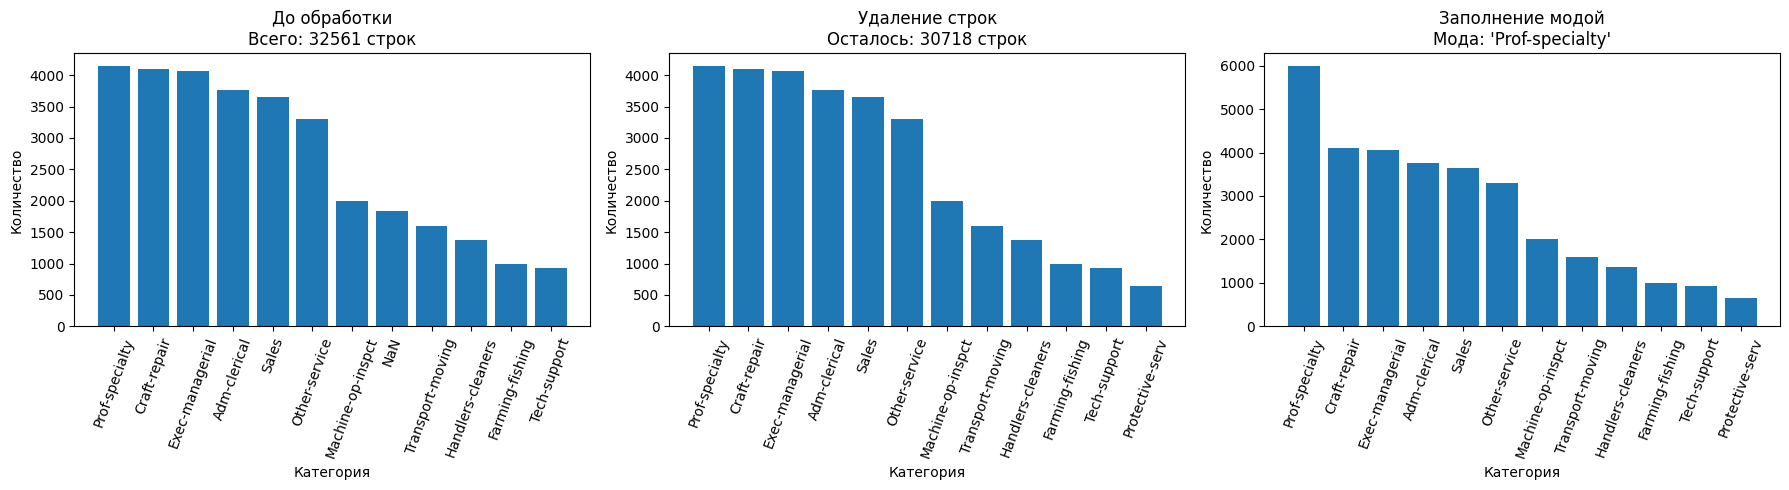


**Комментарий к графикам**  
На первом графике видно исходное распределение категорий признака occupation (включая пропуски).  
При удалении строк (второй график) распределение категорий по смыслу почти не меняется, но уменьшается объём данных (остаётся 30718 строк).  
При заполнении модой (третий график) заметно увеличивается частота самой популярной категории (Prof-specialty):  
- доля моды до обработки ≈ 13.48%  
- доля моды после заполнения модой ≈ 18.37%  




Распределение категорий в процентах:

До обработки (включая NaN):
occupation
Prof-specialty       12.714597
Craft-repair         12.588680
Exec-managerial      12.487331
Adm-clerical         11.578268
Sales                11.209729
Other-service        10.119468
Machine-op-inspct     6.148460
NaN                   5.660146
Name: proportion, dtype: float64

После удаления строк с пропусками:
occupation
Prof-specialty       13.477440
Craft-repair         13.343968
Exec-managerial      13.236539
Adm-clerical         12.272934
Sales                11.882284
Other-service        10.726610
Machine-op-inspct     6.517351
Transport-moving      5.198906
Name: proportion, dtype: float64

После заполнения модой:
occupation
Prof-specialty       18.374743
Craft-repair         12.588680
Exec-managerial      12.487331
Adm-clerical         11.578268
Sales                11.209729
Other-service        10.119468
Machine-op-inspct     6.148460
Transport-moving      4.904641
Name: proportion, dtype: floa

In [7]:
# Задание 1: Сравнение стратегий импутации для категориального признака

# Выбираем признак с пропусками
col_miss = "occupation"

# Считаем, сколько пропусков в выбранном столбце
missing_count = df[col_miss].isna().sum()                 # количество NaN
missing_percent = (missing_count / len(df)) * 100         # доля NaN в процентах
print(f"Пропусков в '{col_miss}': {missing_count} ({missing_percent:.2f}%)")

# Cчитаем частоты категорий до групировки (включая NaN), берем топ-12
vc_before = df[col_miss].value_counts(dropna=False).head(12)

# Удалить строки, где в этом столбце NaN (теряем часть данных)
df_drop = df.dropna(subset=[col_miss]).copy()             # делаем копию после удаления
vc_drop = df_drop[col_miss].value_counts().head(12)       # частоты топ-12 после удаления

# Заполнить пропуски модой (самым частым значением)
mode_value = df[col_miss].mode(dropna=True)[0]            # находим моду без учета NaN
df_mode = df.copy()                                       # копия для заполнения
df_mode[col_miss] = df_mode[col_miss].fillna(mode_value)  # заменяем NaN на моду
vc_mode = df_mode[col_miss].value_counts().head(12)       # частоты топ-12 после заполнения

print(f"Мода для '{col_miss}': {mode_value}")

# Визуализация 1: Гистограммы по категориям в виде столбчатых диаграмм

# Создаем фигуру с 3 графиками
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# До обработки (включая NaN)
# Для наглядности выводим NaN отдельным столбцом: заменим NaN на подпись "NaN"
vc_before_plot = df[col_miss].fillna("NaN").value_counts().head(12)
axes[0].bar(vc_before_plot.index.astype(str), vc_before_plot.values)   # столбчатая “гистограмма”
axes[0].set_title(f"До обработки\nВсего: {len(df)} строк")
axes[0].set_xlabel("Категория")
axes[0].set_ylabel("Количество")
axes[0].tick_params(axis='x', rotation=70)                             # поворачиваем подписи

# Удаление строк
vc_drop_plot = df_drop[col_miss].value_counts().head(12)
axes[1].bar(vc_drop_plot.index.astype(str), vc_drop_plot.values)
axes[1].set_title(f"Удаление строк\nОсталось: {len(df_drop)} строк")
axes[1].set_xlabel("Категория")
axes[1].set_ylabel("Количество")
axes[1].tick_params(axis='x', rotation=70)

# Заполнение модой
vc_mode_plot = df_mode[col_miss].value_counts().head(12)
axes[2].bar(vc_mode_plot.index.astype(str), vc_mode_plot.values)
axes[2].set_title(f"Заполнение модой\nМода: '{mode_value}'")
axes[2].set_xlabel("Категория")
axes[2].set_ylabel("Количество")
axes[2].tick_params(axis='x', rotation=70)

plt.tight_layout()
plt.show()

# --- Текстовый комментарий под графиками (Задание 1) ---
# Посмотрим, как изменились доли топ-категорий и доля моды
orig_share = df[col_miss].value_counts(normalize=True, dropna=True)
drop_share = df_drop[col_miss].value_counts(normalize=True)
mode_share = df_mode[col_miss].value_counts(normalize=True)

mode_before = orig_share.get(mode_value, 0) * 100
mode_after  = mode_share.get(mode_value, 0) * 100

display(Markdown(
f"""
**Комментарий к графикам**
На первом графике видно исходное распределение категорий признака {col_miss} (включая пропуски).
При удалении строк (второй график) распределение категорий по смыслу почти не меняется, но уменьшается объём данных (остаётся {len(df_drop)} строк).
При заполнении модой (третий график) заметно увеличивается частота самой популярной категории ({mode_value}):
- доля моды до обработки ≈ {mode_before:.2f}%
- доля моды после заполнения модой ≈ {mode_after:.2f}%

"""
))
# Сравним распределения в процентах (доли категорий)

print("\nРаспределение категорий в процентах:")

# До обработки: показываем доли, включая NaN
print("\nДо обработки (включая NaN):")
print(df[col_miss].value_counts(dropna=False, normalize=True).head(8) * 100)

# После удаления строк: NaN уже нет, поэтому dropna=False не нужен
print("\nПосле удаления строк с пропусками:")
print(df_drop[col_miss].value_counts(normalize=True).head(8) * 100)

# После заполнения модой: NaN нет, все пропуски заменены
print("\nПосле заполнения модой:")
print(df_mode[col_miss].value_counts(normalize=True).head(8) * 100)

# Итоговый вывод
print("\nВЫВОД ПО ЗАДАНИЮ 1:")

# Печатаем ключевые итоги обработки
print(f"1. Доля пропусков в '{col_miss}': {missing_percent:.2f}%")
print(f"2. Удаление строк: потеряно {missing_count} строк ({missing_percent:.2f}% данных)")
print(f"3. Заполнение модой: добавлено {missing_count} записей категории '{mode_value}'")
print("- Для категориальных признаков с небольшой долей пропусков оба метода часто дают похожую картину.")
print("- fillna(мода) лучше, если важно не терять строки (например, для обучения модели).")
print("- dropna может быть уместен, если пропусков много или строки с пропусками считаются “плохими” по смыслу.")

Задание 2: Детекция и визуализация выбросов
Цель: Научиться находить и аргументированно удалять аномалии. Инструкция:

Выберите числовой признак, наиболее важный для вашей задачи (по корреляции с таргетом).
Найдите выбросы методом IQR и методом Z-Score.
Визуализуйте их на Boxplot и Scatterplot (подсветите выбросы красным цветом).
Посчитайте процент выбросов от общего числа данных.
Вывод: Стоит ли удалять эти строки или они содержат ценную информацию (например, дорогие дома или редкие случаи болезни)?


Выбор числового признака по корреляции с таргетом:
Топ-5 корреляций (по модулю):


,0
education-num,0.335154
age,0.234037
hours-per-week,0.229689
capital-gain,0.223329
capital-loss,0.150526


Выбран признак для анализа выбросов: education-num (corr = 0.335)

Результаты детекции выбросов:
IQR-границы: [4.500; 16.500]
Выбросов по IQR: 1198 (3.68%)
Выбросов по Z-score (|z|>3): 219 (0.67%)


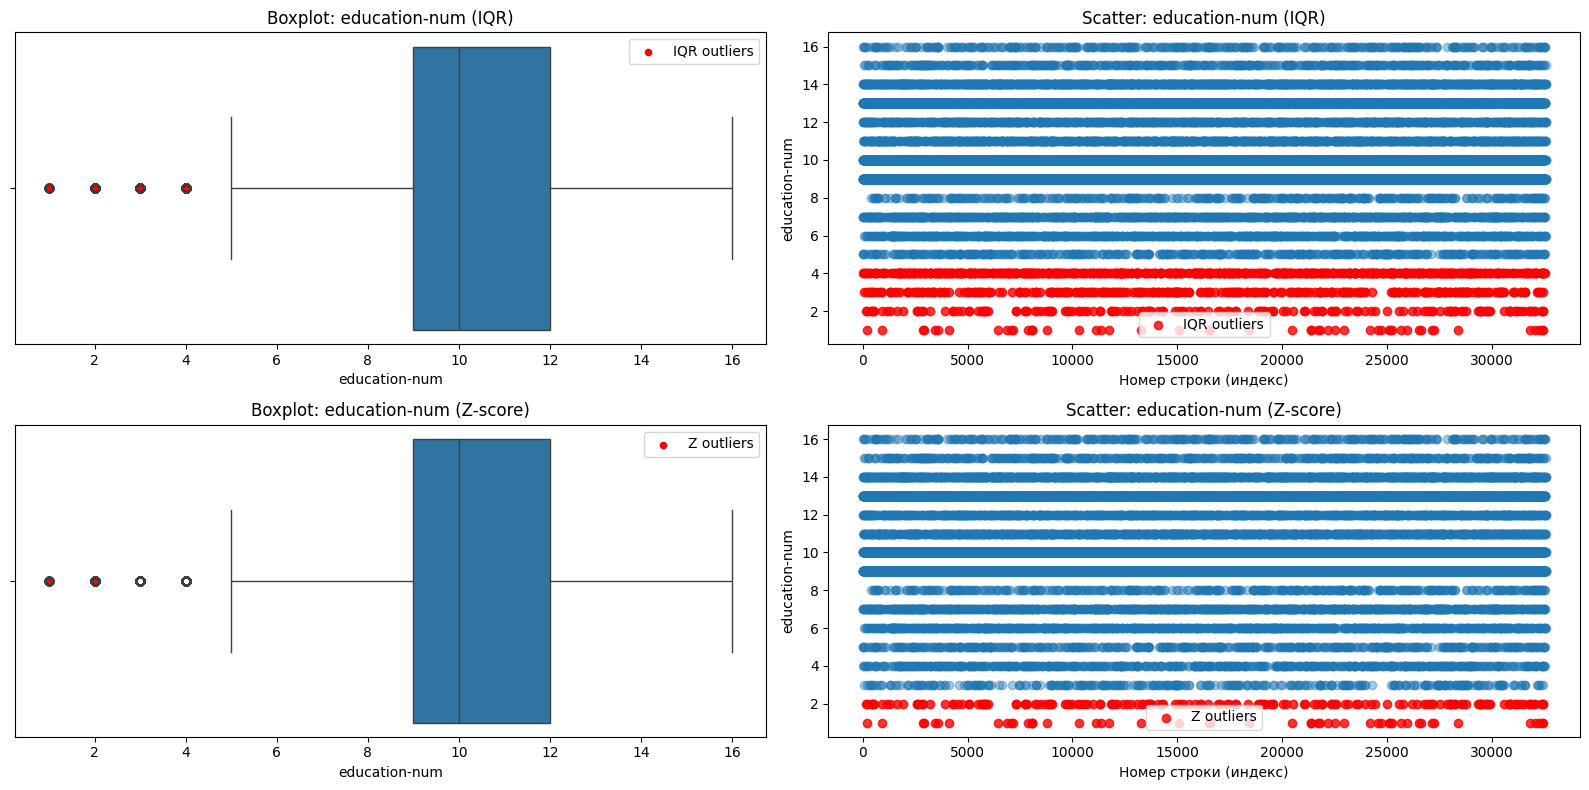


**Комментарий к графикам.**  

Выбранный признак: education-num (корреляция с таргетом income_bin = 0.335).  

- Boxplot (IQR): красные точки — значения ниже 4.500 или выше 16.500, то есть выбросы по методу IQR.  
- Scatter (IQR): красные точки показывают, что выбросы находятся на «краях» распределения (экстремально большие/малые значения).  
- Boxplot/Scatter (Z-score): красные точки — наблюдения с |z| > 3, то есть сильно удалённые от среднего.

Процент выбросов:  
- IQR: 1198 выбросов → 3.68% от всех строк (валидных значений: 32561)  
- Z-score: 219 выбросов → 0.67% от всех строк




ВЫВОД ПО ЗАДАНИЮ 2:
Доля выбросов небольшая (<=5%). Удаление возможно, но стоит проверить смысл выбросов.
Если это реальные редкие случаи (например, очень большие значения), их удалять не всегда правильно.


In [8]:
# Задание 2: Детекция и визуализация выбросов

# Подготовим бинарный таргет (для корреляции с числовыми признаками)
# >50K -> 1, <=50K -> 0
if "income_bin" not in df.columns:
    df["income_bin"] = df["income"].astype(str).str.contains(">50K").astype(int)

# Берем все числовые признаки (кроме самого таргета income_bin)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "income_bin"]

# Считаем корреляцию каждого числового признака с таргетом (income_bin)
corrs = df[num_cols].corrwith(df["income_bin"]).sort_values(key=lambda s: s.abs(), ascending=False)

print("\nВыбор числового признака по корреляции с таргетом:")
print("Топ-5 корреляций (по модулю):")
display(corrs.head(5))

# Выбираем самый важный числовой признак максимальное значение
feature = corrs.index[0]
print(f"Выбран признак для анализа выбросов: {feature} (corr = {corrs.loc[feature]:.3f})")

# Берем значения признака приводим к числу
x = pd.to_numeric(df[feature], errors="coerce")      # если вдруг встретится мусор -> станет NaN
x_valid = x.dropna()                                # для вычислений используем только валидные числа

# Метод 1: IQR Метод межквартильного размаха

q1 = x_valid.quantile(0.25)                         # первый квартиль
q3 = x_valid.quantile(0.75)                         # третий квартиль
iqr = q3 - q1                                       # IQR
lower = q1 - 1.5 * iqr                              # нижняя граница выбросов
upper = q3 + 1.5 * iqr                              # верхняя граница выбросов

mask_iqr = (x < lower) | (x > upper)                # True там, где выброс по IQR
mask_iqr = mask_iqr.fillna(False)                   # NaN считаем не-выбросом для маски

iqr_outliers = int(mask_iqr.sum())                  # количество выбросов
iqr_percent = iqr_outliers / len(x_valid) * 100     # процент выбросов (от валидных значений)

# Метод 2: Z-score Количество стандартных отклонений от среднего

mean_x = x_valid.mean()                             # среднее
std_x = x_valid.std(ddof=0)                         # стандартное отклонение (популяционное)

z = (x - mean_x) / std_x                            # Z-score для каждого значения
mask_z = z.abs() > 3                                # классический порог: |z| > 3
mask_z = mask_z.fillna(False)

z_outliers = int(mask_z.sum())                      # количество выбросов
z_percent = z_outliers / len(x_valid) * 100         # процент выбросов

print("\nРезультаты детекции выбросов:")
print(f"IQR-границы: [{lower:.3f}; {upper:.3f}]")
print(f"Выбросов по IQR: {iqr_outliers} ({iqr_percent:.2f}%)")
print(f"Выбросов по Z-score (|z|>3): {z_outliers} ({z_percent:.2f}%)")

# 5) Визуализация: Boxplot + Scatterplot (выбросы красным)

# Для scatterplot используем индекс строки как ось X (удобно и просто)
idx = np.arange(len(df))

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Boxplot + IQR выбросы красным
sns.boxplot(x=x_valid, ax=axes[0, 0])
axes[0, 0].scatter(x[mask_iqr], np.zeros(iqr_outliers), color="red", s=20, label="IQR outliers")
axes[0, 0].set_title(f"Boxplot: {feature} (IQR)")
axes[0, 0].legend()

# Scatterplot + IQR выбросы красным
axes[0, 1].scatter(idx[~mask_iqr], x[~mask_iqr], alpha=0.4)
axes[0, 1].scatter(idx[mask_iqr], x[mask_iqr], color="red", alpha=0.8, label="IQR outliers")
axes[0, 1].set_title(f"Scatter: {feature} (IQR)")
axes[0, 1].set_xlabel("Номер строки (индекс)")
axes[0, 1].set_ylabel(feature)
axes[0, 1].legend()

# Boxplot + Z-score выбросы красным
sns.boxplot(x=x_valid, ax=axes[1, 0])
axes[1, 0].scatter(x[mask_z], np.zeros(z_outliers), color="red", s=20, label="Z outliers")
axes[1, 0].set_title(f"Boxplot: {feature} (Z-score)")
axes[1, 0].legend()

# Scatterplot + Z-score выбросы красным
axes[1, 1].scatter(idx[~mask_z], x[~mask_z], alpha=0.4)
axes[1, 1].scatter(idx[mask_z], x[mask_z], color="red", alpha=0.8, label="Z outliers")
axes[1, 1].set_title(f"Scatter: {feature} (Z-score)")
axes[1, 1].set_xlabel("Номер строки (индекс)")
axes[1, 1].set_ylabel(feature)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# --- Проценты выбросов от общего числа строк (как требует задание) ---
total_n = len(df)
valid_n = x.notna().sum()

iqr_percent_total = iqr_outliers / total_n * 100
z_percent_total   = z_outliers / total_n * 100

display(Markdown(
f"""
**Комментарий к графикам.**

Выбранный признак: {feature} (корреляция с таргетом income_bin = {corrs.loc[feature]:.3f}).

- Boxplot (IQR): красные точки — значения ниже {lower:.3f} или выше {upper:.3f}, то есть выбросы по методу IQR.
- Scatter (IQR): красные точки показывают, что выбросы находятся на «краях» распределения (экстремально большие/малые значения).
- Boxplot/Scatter (Z-score): красные точки — наблюдения с |z| > 3, то есть сильно удалённые от среднего.

Процент выбросов:
- IQR: {iqr_outliers} выбросов → {iqr_percent_total:.2f}% от всех строк (валидных значений: {valid_n})
- Z-score: {z_outliers} выбросов → {z_percent_total:.2f}% от всех строк

"""
))

print("\nВЫВОД ПО ЗАДАНИЮ 2:")

if iqr_percent > 5 or z_percent > 5:
    print("Выбросов довольно много (>5%). Удаление строк может привести к потере информации.")
    print("Лучше рассмотреть capping (обрезку значений) вместо удаления.")
else:
    print("Доля выбросов небольшая (<=5%). Удаление возможно, но стоит проверить смысл выбросов.")
    print("Если это реальные редкие случаи (например, очень большие значения), их удалять не всегда правильно.")

Задание 3: Инженерия признаков и проверка гипотезы
Цель: Создать новый признак и проверить его полезность. Инструкция:

Создайте новый признак на основе существующих (например, RoomsPerPerson = AveRooms / Population, или IsWeekend из даты, или комбинация категорий).
Постройте корреляционную матрицу с включением нового признака.
Постройте график зависимости нового признака от целевой переменной.
Вывод: Увеличил ли новый признак корреляцию с целевой переменной по сравнению с исходными? Рекомендуете ли вы его для модели?

Топ-10 стран после группировки:


,count
native_country_grp,
United-States,29170
Other,1389
Mexico,643
NaN,583
Philippines,198
Germany,137
Canada,121
Puerto-Rico,114
El-Salvador,106



Топ-15 корреляций с income_bin (по модулю):


,income_bin
income_bin,1.000000
education-num,0.335154
age,0.234037
hours-per-week,0.229689
capital-gain,0.223329
capital_net,0.214428
capital-loss,0.150526
ctry_Mexico,-0.062901
ctry_United-States,0.034470
ctry_El-Salvador,-0.020838


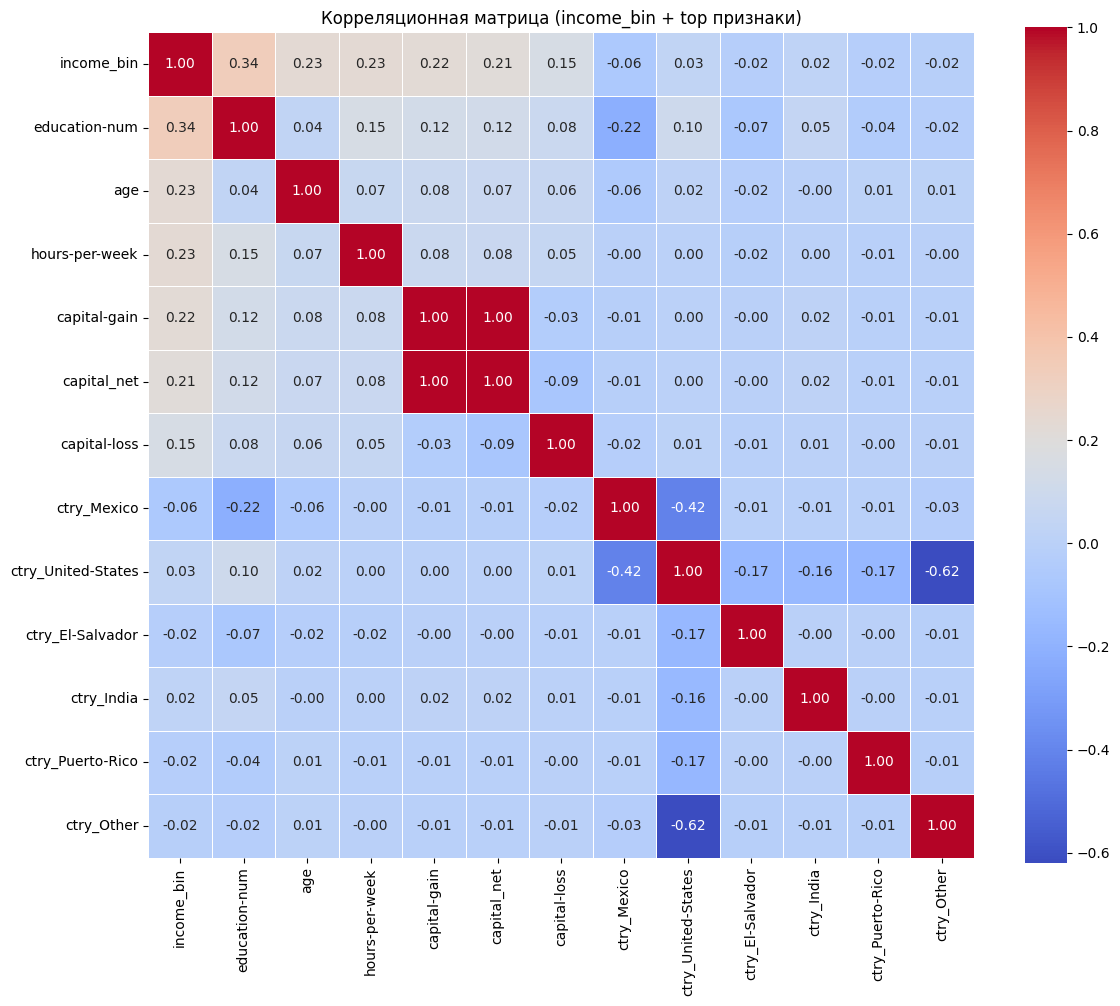


Статистика нового признака по классам income_bin:


,count,mean,median
income_bin,,,
0,24720,95.609547,0.0
1,7841,3811.140926,0.0


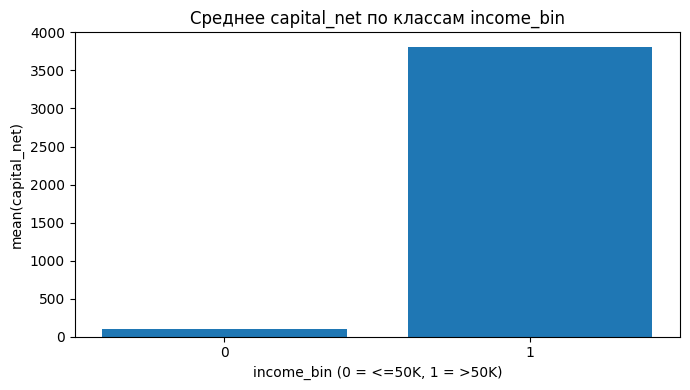

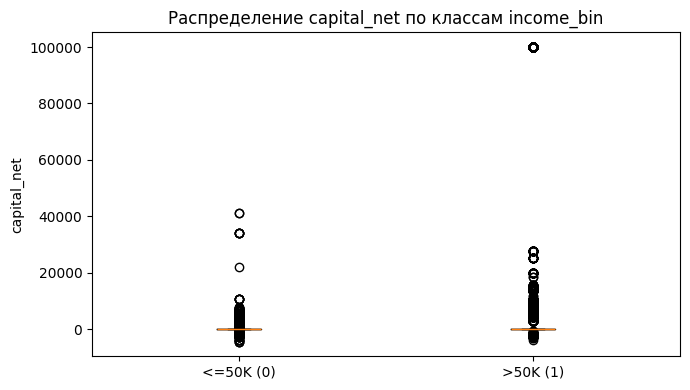


Сравнение корреляций с income_bin:


,income_bin
capital-gain,0.223329
capital_net,0.214428
capital-loss,0.150526



ВЫВОД ПО ЗАДАНИЮ 3:
Новый признак 'capital_net' не улучшил корреляцию: |corr|=0.2144, а лучший из исходных имеет 0.2233.
Рекомендация: по линейной корреляции выигрыша нет; может быть полезен в нелинейных моделях, но не обязателен.


In [4]:
# Задание 3: Инженерия признаков и проверка гипотезы

# Убедимся, что бинарный таргет есть
if "income_bin" not in df.columns:
    df["income_bin"] = df["income"].astype(str).str.contains(">50K").astype(int)

# Специфическое требование: группировка редких категорий в 'native-country'

col_country = "native-country"
min_count = 100  # порог редкости

country_counts = df[col_country].value_counts(dropna=False)
rare_countries = country_counts[country_counts < min_count].index

df["native_country_grp"] = df[col_country].copy()
df.loc[df["native_country_grp"].isin(rare_countries), "native_country_grp"] = "Other"
# Если хотите NaN тоже в Other:
# df["native_country_grp"] = df["native_country_grp"].fillna("Other")

print("Топ-10 стран после группировки:")
display(df["native_country_grp"].value_counts(dropna=False).head(10))

# Новый признак

df["capital_net"] = df["capital-gain"].fillna(0) - df["capital-loss"].fillna(0)
new_feature = "capital_net"

# Корреляции и матрица корреляций

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

country_dummies = pd.get_dummies(df["native_country_grp"], prefix="ctry", dummy_na=True)
corr_df = pd.concat([df[num_cols], country_dummies], axis=1)

corr_with_target = (
    corr_df.corr(numeric_only=True)["income_bin"]
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("\nТоп-15 корреляций с income_bin (по модулю):")
display(corr_with_target.head(15))

topN = 12
top_features = corr_with_target.drop("income_bin").head(topN).index.tolist()

corr_matrix = corr_df[["income_bin"] + top_features].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5)
plt.title("Корреляционная матрица (income_bin + top признаки)")
plt.tight_layout()
plt.show()

# График зависимости нового признака от целевой переменной

group_stats = df.groupby("income_bin")[new_feature].agg(["count", "mean", "median"])
print("\nСтатистика нового признака по классам income_bin:")
display(group_stats)

plt.figure(figsize=(7, 4))
plt.bar(group_stats.index.astype(str), group_stats["mean"])
plt.title(f"Среднее {new_feature} по классам income_bin")
plt.xlabel("income_bin (0 = <=50K, 1 = >50K)")
plt.ylabel(f"mean({new_feature})")
plt.tight_layout()
plt.show()

vals0 = df.loc[df["income_bin"] == 0, new_feature].dropna()
vals1 = df.loc[df["income_bin"] == 1, new_feature].dropna()

plt.figure(figsize=(7, 4))
plt.boxplot([vals0, vals1], tick_labels=["<=50K (0)", ">50K (1)"], showfliers=True)
plt.title(f"Распределение {new_feature} по классам income_bin")
plt.ylabel(new_feature)
plt.tight_layout()
plt.show()

# Проверка гипотезы: Увеличил ли новый признак корреляцию с целевой переменной по сравнению с исходными

base_feats = ["capital-gain", "capital-loss", new_feature]
base_corrs = df[base_feats + ["income_bin"]].corr(numeric_only=True)["income_bin"].drop("income_bin")

print("\nСравнение корреляций с income_bin:")
display(base_corrs.sort_values(key=lambda s: s.abs(), ascending=False))

best_base = base_corrs.drop(new_feature).abs().max()
new_corr_abs = abs(base_corrs[new_feature])

print("\nВЫВОД ПО ЗАДАНИЮ 3:")

if new_corr_abs > best_base:
    print(
        f"Новый признак '{new_feature}' усилил связь с таргетом: |corr|={new_corr_abs:.4f} "
        f"(лучше, чем у исходных capital-gain/capital-loss: {best_base:.4f})."
    )
    print("Рекомендация: признак стоит использовать в модели.")
else:
    print(
        f"Новый признак '{new_feature}' не улучшил корреляцию: |corr|={new_corr_abs:.4f}, "
        f"а лучший из исходных имеет {best_base:.4f}."
    )
    print("Рекомендация: по линейной корреляции выигрыша нет; может быть полезен в нелинейных моделях, но не обязателен.")